# **Lab 2 – Tidying, Cleaning, Imputation, and Outlier Detection**

## Machine Learning Programming

This assignment continues the work started in **`week5Lab.ipynb`**.  
Open this notebook and complete the activities **in this notebook**, preserving the section order and the overall structure.

The purpose of this lab is to practice the data-preprocessing work that normally takes place before machine learning: reshaping data, cleaning inconsistent values, handling missing data, detecting outliers, visualizing results, and explaining the decisions you make.

## **Assignment Overview**

### Purpose
By the end of this lab, you should be able to take several imperfect datasets and make them more suitable for analysis and later machine-learning work.

### Learning Outcomes
You will practice how to:

- inspect the shape, columns, data types, and quality of a dataset;
- distinguish **wide** and **long/tidy** data;
- reshape data with `pd.melt()` or `DataFrame.melt()`;
- clean strings using Pandas string methods;
- identify, quantify, drop, and impute missing values;
- compare mean, median, mode, and `SimpleImputer` approaches;
- identify outliers visually with box plots and scatter plots;
- identify outliers statistically using **Z-Scores** and **IQR**;
- justify preprocessing decisions using evidence from the data;
- document a reproducible Python data-processing workflow.

### Estimated Completion Time
Approximately **2.5–3.5 hours**, depending on your Python experience.

## **Submission and Project Structure**

Keep the project organized so another person can reproduce your work.

Recommended structure:

```text
project/
├── week5Lab.ipynb
├── README.md
├── requirements.txt
├── .gitignore
└── data/
    ├── pew-raw.csv
    ├── billboard.csv
    ├── cars.csv
    └── diabetes.csv
```

A clearly named equivalent data folder such as `CSVs/` or `datasets/` is also acceptable if all notebook paths are updated consistently.

### Required submission artifacts

- `week5Lab.ipynb` containing **all four completed sections**
- `README.md` with at least 1–2 meaningful sentences describing the lab and how to run it
- `requirements.txt` containing the packages required to reproduce the environment
- `.gitignore`
- all required data files inside a clearly named data folder

**Important:** Use relative paths such as `./data/cars.csv`. Do not use absolute paths from your own computer.

**Environment practice:** Use `requirements.txt` to define the environment. Do not add `!pip install ...` cells to the notebook when a requirements file is provided.

## **Before You Begin**

Use the following libraries where appropriate:

- `pandas`
- `numpy`
- `matplotlib`
- `seaborn`
- `scikit-learn`

Run the import cell below before beginning the exercises.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.impute import SimpleImputer

# Optional display settings
pd.set_option("display.max_columns", None)

## **General Expectations**

For every section:

1. Write the required Python code.
2. Display enough output to demonstrate that the code works.
3. Add short Markdown explanations in your own words.
4. Label plots clearly with a title and axis labels.
5. Explain what the output means instead of only producing it.
6. Preserve the required section headings so the notebook is easy to follow.
7. Before submitting, restart the kernel and use **Run All** to confirm the notebook executes from beginning to end.

# **Section 1 – PEW Research Dataset**

## **Learning Topic: Data Tidying and Reshaping**

A dataset is commonly described as **tidy** when:

1. each variable forms a column;
2. each observation forms a row; and
3. each type of observational unit forms a table.

The PEW dataset represents counts for religions across income ranges. In its original form, income values appear as column headings. You will reshape the dataset from **wide** format to **long/tidy** format using `melt()`.

### Required concepts
- dataset inspection
- wide versus long data
- identifier variables
- measured variables
- `pd.melt()` or `DataFrame.melt()`
- visualization after reshaping

## **Getting the PEW Dataset from the Internet**

For this lab, use the small **PEW religion-and-income dataset** commonly used to demonstrate tidy-data principles. This is the dataset whose first column is `religion` and whose remaining columns are income ranges such as `<$10k`, `$10-20k`, and `$20-30k`.

### Recommended method — download in your browser

1. Open the dataset in a browser:
   `https://raw.githubusercontent.com/nickhould/tidy-data-python/master/data/pew-raw.csv`
2. Save the file as **`pew-raw.csv`**.
3. Create a folder named **`data`** in the same project folder as this notebook if it does not already exist.
4. Move `pew-raw.csv` into the `data` folder.
5. Confirm that your project contains:

```text
project/
├── week5Lab.ipynb
└── data/
    └── pew-raw.csv
```

6. Load the local copy with:

```python
df_pew = pd.read_csv("./data/pew-raw.csv")
```

### Optional Python-assisted download

The following is an example only. You may use it once to obtain the dataset, but your submitted analysis should subsequently read the **local copy** from `./data/`.

```python
from pathlib import Path
import pandas as pd

Path("data").mkdir(exist_ok=True)

url = "https://raw.githubusercontent.com/nickhould/tidy-data-python/master/data/pew-raw.csv"
df_pew = pd.read_csv(url)
df_pew.to_csv("./data/pew-raw.csv", index=False)
```

### Verify before continuing

After loading the file, check that the dataframe contains a `religion` column and multiple income-range columns. If it does not, stop and verify that you downloaded the correct dataset.

> **Good reproducibility practice:** Do not depend on the Internet every time the notebook runs. Download the dataset once, store it in the project's `data/` folder, commit the permitted data file to your repository, and use a relative path in the notebook.

### **Task 1.1 – Load and Inspect the Dataset**

1. Load the PEW dataset from your data folder.
2. Display its shape.
3. Display its column names.
4. Display several rows using `head()`, `loc`, `iloc`, or `tail()`.
5. Identify the column that should remain the identifier variable.

In [5]:
# Define the relative path to the PEW dataset
pew_path = Path("data") / "pew-raw.csv"

# Verify that the required file exists before attempting to load it
if not pew_path.exists():
    raise FileNotFoundError(
        f"PEW dataset was not found at: {pew_path.resolve()}"
    )

# Load the dataset
df_pew = pd.read_csv(pew_path)

# Remove accidental leading/trailing whitespace from column names
df_pew.columns = df_pew.columns.str.strip()

# Inspect the dataset
print("PEW Dataset Shape:")
print(df_pew.shape)

print("\nPEW Dataset Columns:")
print(df_pew.columns.tolist())

print("\nFirst Five Rows:")
display(df_pew.head())

print("\nIdentifier Variable:")
print("religion")

PEW Dataset Shape:
(10, 7)

PEW Dataset Columns:
['religion', '<$10k', '$10-20k', '$20-30k', '$30-40k', '$40-50k', '$50-75k']

First Five Rows:


,religion,<$10k,$10-20k,$20-30k,$30-40k,$40-50k,$50-75k
0,Agnostic,27,34,60,81,76,137
1,Atheist,12,27,37,52,35,70
2,Buddhist,27,21,30,34,33,58
3,Catholic,418,617,732,670,638,1116
4,Dont know/refused,15,14,15,11,10,35



Identifier Variable:
religion


The PEW dataset contains 10 rows and 7 columns. The `religion` column identifies each observation, while the remaining six columns contain counts for different income categories. During inspection, leading and trailing whitespace was removed from the column names to ensure consistent column references in later processing steps.

### **Task 1.2 – Explain the Problem**

In a Markdown cell below, answer:

- What is not tidy about the original PEW dataset?
- Which values are stored in column names?
- Which column should be treated as the identifier (`id_vars`)?

1. **What is not tidy about the original PEW dataset?**  
   The original PEW dataset is not tidy because the different income categories are stored as separate columns. In tidy data, values of the same variable should be stored in one column.

2. **Which values are stored in column names?**  
   The income ranges are stored in the column names, such as `<$10k`, `$10-20k`, `$20-30k`, `$30-40k`, `$40-50k`, and `$50-75k`.

3. **Which column should be treated as the identifier (`id_vars`)?**  
   The `religion` column should be treated as the identifier variable because it identifies each religion and should remain unchanged when the dataset is reshaped.

### **Task 1.3 – Reshape with `melt()`**

Use either of these valid Pandas forms:

```python
pd.melt(...)
```

or

```python
df.melt(...)
```

Your result should have meaningful names for the new variable and value columns, such as `income` and `count`.

In [6]:
# Reshape the PEW dataframe from wide to long format
df_pew_tidy = df_pew.melt(
    id_vars="religion",
    var_name="income",
    value_name="count"
)

# Display the first rows of the reshaped dataframe
print("First Rows of the Reshaped PEW Dataset:")
display(df_pew_tidy.head(10))

# Compare original and reshaped shapes
print("Original Shape:", df_pew.shape)
print("Reshaped Shape:", df_pew_tidy.shape)

First Rows of the Reshaped PEW Dataset:


,religion,income,count
0,Agnostic,<$10k,27
1,Atheist,<$10k,12
2,Buddhist,<$10k,27
3,Catholic,<$10k,418
4,Dont know/refused,<$10k,15
5,Evangelical Prot,<$10k,575
6,Hindu,<$10k,1
7,Historically Black Prot,<$10k,228
8,Jehovahs Witness,<$10k,20
9,Jewish,<$10k,19


Original Shape: (10, 7)
Reshaped Shape: (60, 3)


The PEW dataset was reshaped from wide format to long format using `melt()`. The `religion` column was preserved as the identifier, while the six income-category columns were converted into values in the new `income` column. Their corresponding observations were stored in the `count` column.

The dataset changed from 10 rows and 7 columns to 60 rows and 3 columns because each religion now has one separate row for each of the six income categories.

### **Task 1.4 – Visualize the Tidy Data**

Create at least **one meaningful visualization** from the reshaped dataset.

Possible questions include:

- How do counts differ across income groups?
- How do selected religions compare across income groups?

Your plot must include a title and axis labels.

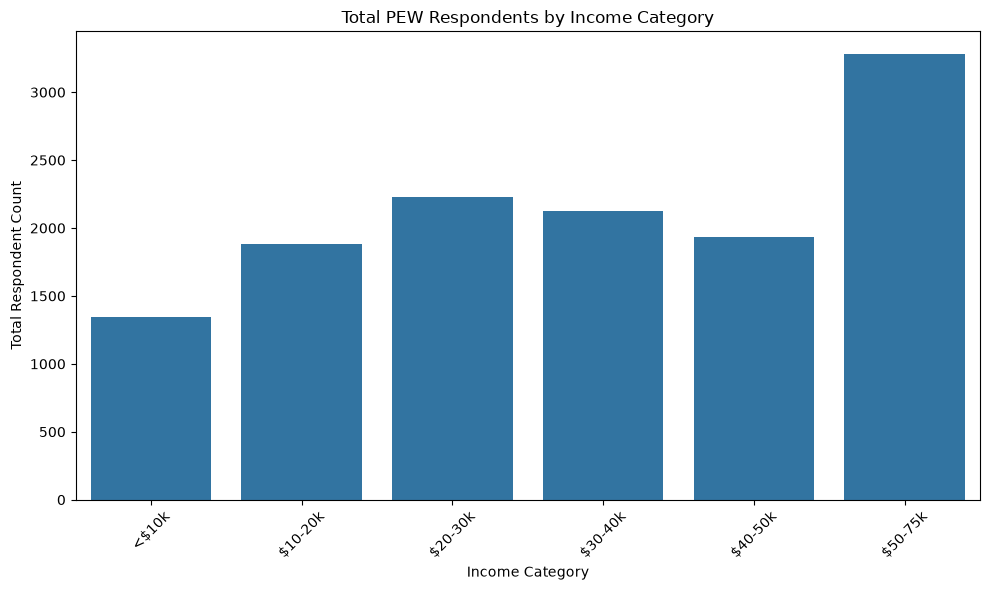

In [8]:
# Preserve the original logical order of the income categories
income_order = [
    column for column in df_pew.columns
    if column != "religion"
]

# Calculate the total respondent count for each income category
income_totals = (
    df_pew_tidy.groupby("income", as_index=False, sort=False)["count"]
    .sum()
)

# Create the visualization
plt.figure(figsize=(10, 6))

sns.barplot(
    data=income_totals,
    x="income",
    y="count",
    order=income_order
)

plt.title("Total PEW Respondents by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Total Respondent Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The bar chart compares the total number of PEW respondents across the six income categories. The `$50-75k` category has the highest total respondent count, while the `<$10k` category has the lowest. Reshaping the dataset into tidy format makes this comparison easier because all income categories are represented as values of a single `income` variable.

### **Task 1.5 – PEW Reflection**

Answer **all** questions briefly in your own words:

1. What was the main structural problem with the original dataset?
2. What does `id_vars` mean in `melt()`?
3. What information moved from columns into rows?
4. How did the number of rows change after reshaping, and why?
5. Why is the long format easier to analyze or visualize?
6. What did your visualization reveal?

> **PEW Observations and Reflection**
>
> 1. **What was the main structural problem with the original dataset?**  
>    The original dataset was in wide format, with each income category stored as a separate column. This is not tidy because the income categories are values of the same variable.
>
> 2. **What does `id_vars` mean in `melt()`?**  
>    `id_vars` specifies the column or columns that should remain unchanged while the other columns are reshaped. In this dataset, `religion` is the identifier variable.
>
> 3. **What information moved from columns into rows?**  
>    The income categories, such as `<$10k`, `$10-20k`, `$20-30k`, `$30-40k`, `$40-50k`, and `$50-75k`, moved from separate column names into values in the `income` column.
>
> 4. **How did the number of rows change after reshaping, and why?**  
>    The dataset changed from 10 rows to 60 rows. This happened because each of the 10 religions now has one row for each of the six income categories.
>
> 5. **Why is the long format easier to analyze or visualize?**  
>    Long format stores similar observations in the same columns, which makes it easier to filter, group, summarize, and create visualizations using tools such as Pandas and Seaborn.
>
> 6. **What did your visualization reveal?**  
>    The visualization showed that the `$50-75k` income category had the highest total respondent count, while the `<$10k` category had the lowest total respondent count.

# **Section 2 – Billboard Dataset**

## **Learning Topic: Advanced Data Tidying**

The Billboard dataset stores weekly song rankings across many week columns. You will reshape those columns into rows, clean the resulting week labels, convert ranking values to appropriate data types, handle missing values, and analyze ranking trends.

### Required concepts
- `pd.melt()` or `DataFrame.melt()`
- Pandas string methods such as:
  - `.str.replace()`
  - `.str.strip()`
  - `.str.extract()`
  - `.str.upper()`
  - `.str.lower()`
- numeric conversion
- missing-value handling
- dates / timedeltas where appropriate

## **Getting the Billboard Dataset from the Internet**

Use the **Billboard weekly ranking dataset** associated with the classic tidy-data example. The correct file contains song information plus many weekly ranking columns such as `1st week`, `2nd week`, etc. (column names can vary slightly between copies).

### Recommended method — download in your browser

1. Open this public copy of `billboard.csv`:
   `https://gist.githubusercontent.com/AdrianLl/bd94c12f2b3c3a899c4ca13d0a548966/raw/billboard.csv`
2. Save the file as **`billboard.csv`**.
3. Place it inside your project's **`data`** folder.
4. Your project should now include:

```text
project/
├── week5Lab.ipynb
└── data/
    ├── pew-raw.csv
    └── billboard.csv
```

5. Load the local file. If ordinary UTF-8 decoding fails, try `encoding="unicode_escape"`:

```python
billboard = pd.read_csv("./data/billboard.csv", encoding="unicode_escape")
```

### Optional Python-assisted download

```python
from pathlib import Path
import pandas as pd

Path("data").mkdir(exist_ok=True)

url = "https://gist.githubusercontent.com/AdrianLl/bd94c12f2b3c3a899c4ca13d0a548966/raw/billboard.csv"
billboard = pd.read_csv(url, encoding="unicode_escape")
billboard.to_csv("./data/billboard.csv", index=False)
```

### Verify before continuing

Inspect `billboard.columns`. You should see identifying information for songs/artists and a sequence of weekly ranking columns. Those repeated week columns are the columns you will later reshape with `melt()`.

> **Important:** Different online copies sometimes use slightly different column names. Do not blindly copy column names from an example. Inspect **your downloaded file** first and adapt your code accordingly.

### **Task 2.1 – Load and Inspect Billboard Data**

1. Load the Billboard dataset.
2. If normal UTF-8 decoding fails, try `encoding="unicode_escape"`.
3. Display its shape, columns, and first rows.
4. Identify the columns that represent weekly rankings.

In [10]:
# Define the relative path to the Billboard dataset
billboard_path = Path("data") / "billboard.csv"

# Verify that the dataset exists
if not billboard_path.exists():
    raise FileNotFoundError(
        f"Billboard dataset was not found at: {billboard_path.resolve()}"
    )

# Try normal UTF-8 decoding first.
# If it fails, use the encoding suggested in the assignment.
try:
    billboard = pd.read_csv(billboard_path)
    print("Dataset loaded using UTF-8 encoding.")
except UnicodeDecodeError:
    billboard = pd.read_csv(
        billboard_path,
        encoding="unicode_escape"
    )
    print("UTF-8 decoding failed. Dataset loaded using unicode_escape.")

# Inspect the dataset
print("\nBillboard Dataset Shape:")
print(billboard.shape)

print("\nBillboard Dataset Columns:")
print(billboard.columns.tolist())

print("\nBillboard Data Types:")
display(billboard.dtypes.to_frame(name="Data Type"))

print("\nFirst Five Rows:")
display(billboard.head())

# Identify only the columns that represent weekly chart rankings
weekly_columns = billboard.columns[
    billboard.columns.str.match(
        r"^\d+(st|nd|rd|th)\s+week$",
        case=False,
        na=False
    )
].tolist()

print("\nWeekly Ranking Columns:")
print(weekly_columns)

print("\nNumber of Weekly Ranking Columns:")
print(len(weekly_columns))

Dataset loaded using UTF-8 encoding.

Billboard Dataset Shape:
(317, 77)

Billboard Dataset Columns:
['artist', 'track', 'duration', 'genre', 'date entered', 'date peaked', 'weeks to peak', 'weeks on chart', 'worst position', 'best position', 'enter rank', 'exit rank', '1st week', '2nd week', '3rd week', '4th week', '5th week', '6th week', '7th week', '8th week', '9th week', '10th week', '11th week', '12th week', '13th week', '14th week', '15th week', '16th week', '17th week', '18th week', '19th week', '20th week', '21st week', '22nd week', '23rd week', '24th week', '25th week', '26th week', '27th week', '28th week', '29th week', '30th week', '31st week', '32nd week', '33rd week', '34th week', '35th week', '36th week', '37th week', '38th week', '39th week', '40th week', '41st week', '42nd week', '43rd week', '44th week', '45th week', '46th week', '47th week', '48th week', '49th week', '50th week', '51st week', '52nd week', '53rd week', '54th week', '55th week', '56th week', '57th week'

,Data Type
artist,str
track,str
duration,int64
genre,str
date entered,str
...,...
61st week,float64
62nd week,float64
63rd week,float64
64th week,float64



First Five Rows:


,artist,track,duration,genre,date entered,date peaked,weeks to peak,weeks on chart,worst position,best position,enter rank,exit rank,1st week,2nd week,3rd week,4th week,5th week,6th week,7th week,8th week,9th week,10th week,11th week,12th week,13th week,14th week,15th week,16th week,17th week,18th week,19th week,20th week,21st week,22nd week,23rd week,24th week,25th week,26th week,27th week,28th week,29th week,30th week,31st week,32nd week,33rd week,34th week,35th week,36th week,37th week,38th week,39th week,40th week,41st week,42nd week,43rd week,44th week,45th week,46th week,47th week,48th week,49th week,50th week,51st week,52nd week,53rd week,54th week,55th week,56th week,57th week,58th week,59th week,60th week,61st week,62nd week,63rd week,64th week,65th week
0,Destiny's Child,Independent Women Part I,218,Rock,9/23/2000,11/18/2000,8,28,78,1,78,31,78,63.0,49.0,33.0,23.0,15.0,7.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,3.0,7.0,10.0,12.0,15.0,22.0,29.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Santana,"Maria, Maria",258,Rock,2/12/2000,4/8/2000,8,26,48,1,15,47,15,8.0,6.0,5.0,2.0,3.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,8.0,15.0,19.0,21.0,26.0,36.0,48.0,47.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Savage Garden,I Knew I Loved You,247,Rock,10/23/1999,1/29/2000,14,33,71,1,71,47,71,48.0,43.0,31.0,20.0,13.0,7.0,6.0,4.0,4.0,4.0,6.0,4.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,4.0,8.0,8.0,12.0,14.0,17.0,21.0,24.0,30.0,34.0,37.0,46.0,47.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Madonna,Music,225,Rock,8/12/2000,9/16/2000,5,24,44,1,41,44,41,23.0,18.0,14.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,4.0,8.0,11.0,16.0,20.0,25.0,27.0,27.0,29.0,44.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Aguilera, Christina",Come On Over Baby (All I Want Is You),218,Rock,8/5/2000,10/14/2000,10,21,57,1,57,44,57,47.0,45.0,29.0,23.0,18.0,11.0,9.0,9.0,11.0,1.0,1.0,1.0,1.0,4.0,8.0,12.0,22.0,23.0,43.0,44.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Weekly Ranking Columns:
['1st week', '2nd week', '3rd week', '4th week', '5th week', '6th week', '7th week', '8th week', '9th week', '10th week', '11th week', '12th week', '13th week', '14th week', '15th week', '16th week', '17th week', '18th week', '19th week', '20th week', '21st week', '22nd week', '23rd week', '24th week', '25th week', '26th week', '27th week', '28th week', '29th week', '30th week', '31st week', '32nd week', '33rd week', '34th week', '35th week', '36th week', '37th week', '38th week', '39th week', '40th week', '41st week', '42nd week', '43rd week', '44th week', '45th week', '46th week', '47th week', '48th week', '49th week', '50th week', '51st week', '52nd week', '53rd week', '54th week', '55th week', '56th week', '57th week', '58th week', '59th week', '60th week', '61st week', '62nd week', '63rd week', '64th week', '65th week']

Number of Weekly Ranking Columns:
65


The Billboard dataset contains 317 rows and 77 columns. Twelve columns describe each song and its overall chart information, while 65 columns (`1st week` through `65th week`) contain the weekly chart rankings. The variables `weeks to peak` and `weeks on chart` are summary attributes and are not part of the repeated weekly ranking columns.

### **Task 2.2 – Diagnose the Tidiness Problem**

Explain why having columns such as week 1, week 2, week 3, etc. makes the dataset difficult to analyze.

Identify:

- identifier columns;
- weekly measured columns; and
- the variables you want after reshaping.

### Billboard Tidiness Diagnosis

The Billboard dataset is not tidy because the weekly chart rankings are stored in separate columns such as `1st week`, `2nd week`, `3rd week`, and so on. The week number is therefore encoded in the column names instead of being stored as a variable.

The identifier and song-level columns are:

- `artist`
- `track`
- `duration`
- `genre`
- `date entered`
- `date peaked`
- `weeks to peak`
- `weeks on chart`
- `worst position`
- `best position`
- `enter rank`
- `exit rank`

The weekly measured columns are the 65 ranking columns from `1st week` through `65th week`.

After reshaping, the repeated weekly ranking columns should become two variables:

- `Week` — the week number for the chart observation.
- `Rank` — the song's chart position during that week.

The song-level identifier columns should remain unchanged so that each weekly ranking can still be linked to the correct song and artist.

### **Task 2.3 – Reshape with `melt()`**

Reshape the weekly ranking columns into a long structure.

Your result should contain:

- the song/artist identifiers;
- a `Week`-type column; and
- a `Rank`-type column.

In [11]:
# Identify song-level identifier columns
id_vars = [
    column for column in billboard.columns
    if column not in weekly_columns
]

# Reshape the 65 weekly ranking columns from wide to long format
billboard_long = billboard.melt(
    id_vars=id_vars,
    value_vars=weekly_columns,
    var_name="Week",
    value_name="Rank"
)

# Inspect the reshaped dataset
print("Identifier Columns:")
print(id_vars)

print("\nNumber of Identifier Columns:")
print(len(id_vars))

print("\nOriginal Billboard Shape:")
print(billboard.shape)

print("\nReshaped Billboard Shape:")
print(billboard_long.shape)

print("\nFirst Ten Rows of the Reshaped Dataset:")
display(billboard_long.head(10))

Identifier Columns:
['artist', 'track', 'duration', 'genre', 'date entered', 'date peaked', 'weeks to peak', 'weeks on chart', 'worst position', 'best position', 'enter rank', 'exit rank']

Number of Identifier Columns:
12

Original Billboard Shape:
(317, 77)

Reshaped Billboard Shape:
(20605, 14)

First Ten Rows of the Reshaped Dataset:


,artist,track,duration,genre,date entered,date peaked,weeks to peak,weeks on chart,worst position,best position,enter rank,exit rank,Week,Rank
0,Destiny's Child,Independent Women Part I,218,Rock,9/23/2000,11/18/2000,8,28,78,1,78,31,1st week,78.0
1,Santana,"Maria, Maria",258,Rock,2/12/2000,4/8/2000,8,26,48,1,15,47,1st week,15.0
2,Savage Garden,I Knew I Loved You,247,Rock,10/23/1999,1/29/2000,14,33,71,1,71,47,1st week,71.0
3,Madonna,Music,225,Rock,8/12/2000,9/16/2000,5,24,44,1,41,44,1st week,41.0
4,"Aguilera, Christina",Come On Over Baby (All I Want Is You),218,Rock,8/5/2000,10/14/2000,10,21,57,1,57,44,1st week,57.0
5,Janet,Doesn't Really Matter,257,Rock,6/17/2000,8/26/2000,10,24,59,1,59,41,1st week,59.0
6,Destiny's Child,Say My Name,271,Rock'n'roll,12/25/1999,3/18/2000,12,32,83,1,83,47,1st week,83.0
7,"Iglesias, Enrique",Be With You,216,Latin,4/1/2000,6/24/2000,12,20,63,1,63,28,1st week,63.0
8,Sisqo,Incomplete,232,Rock'n'roll,6/24/2000,8/12/2000,7,26,77,1,77,46,1st week,77.0
9,Lonestar,Amazed,265,Country,6/5/1999,3/4/2000,39,55,81,1,81,50,1st week,81.0


The Billboard dataset was reshaped from wide format to long format using `melt()`. The 12 song-level columns were preserved as identifier variables, while the 65 weekly ranking columns were converted into two new variables: `Week` and `Rank`.

The dataset changed from 317 rows and 77 columns to 20,605 rows and 14 columns. This occurred because each of the 317 songs now has one potential observation for each of the 65 chart weeks.

### **Task 2.4 – Clean the Week Labels with String Operations**

Use Pandas string manipulation to clean the week labels.

Demonstrate **at least three** relevant string operations. Examples include:

```python
.str.replace(...)
.str.strip()
.str.extract(...)
.str.lower()
.str.upper()
```

Convert the extracted week number to a numeric type after cleaning.

In [12]:
# Create a copy of the original Week labels for comparison
billboard_long["Week_Original"] = billboard_long["Week"]

# 1. Remove leading and trailing whitespace
billboard_long["Week"] = billboard_long["Week"].str.strip()

# 2. Standardize the text to lowercase
billboard_long["Week"] = billboard_long["Week"].str.lower()

# 3. Remove the word "week"
billboard_long["Week"] = (
    billboard_long["Week"]
    .str.replace("week", "", regex=False)
    .str.strip()
)

# 4. Extract the numeric portion of the week label
billboard_long["Week_Number"] = (
    billboard_long["Week"]
    .str.extract(r"(\d+)", expand=False)
)

# Convert the extracted week number to numeric
billboard_long["Week_Number"] = pd.to_numeric(
    billboard_long["Week_Number"],
    errors="coerce"
)

# Display examples of the cleaning process
display(
    billboard_long[
        ["Week_Original", "Week", "Week_Number"]
    ].drop_duplicates().head(15)
)

print("Week_Number Data Type:")
print(billboard_long["Week_Number"].dtype)

print("\nWeek Number Range:")
print(
    billboard_long["Week_Number"].min(),
    "to",
    billboard_long["Week_Number"].max()
)

print("\nMissing Week Numbers:")
print(billboard_long["Week_Number"].isna().sum())

,Week_Original,Week,Week_Number
0,1st week,1st,1
317,2nd week,2nd,2
634,3rd week,3rd,3
951,4th week,4th,4
1268,5th week,5th,5
1585,6th week,6th,6
1902,7th week,7th,7
2219,8th week,8th,8
2536,9th week,9th,9
2853,10th week,10th,10


Week_Number Data Type:
int64

Week Number Range:
1 to 65

Missing Week Numbers:
0


The week labels were cleaned using multiple Pandas string operations, including `str.strip()`, `str.lower()`, `str.replace()`, and `str.extract()`. The numeric portion of each label was then converted to an integer.

The resulting `Week_Number` variable ranges from 1 to 65 with no missing values, confirming that all 65 weekly ranking columns were converted successfully.

### **Task 2.5 – Clean Ranking Values and Missing Data**

1. Convert ranking values to numeric using an appropriate method such as `pd.to_numeric()`.
2. Identify missing rankings.
3. Decide whether missing ranking rows should be dropped, retained, or treated another way.
4. Explain your decision.

In [13]:
# Create a copy for cleaned Billboard observations
billboard_clean = billboard_long.copy()

# Convert Rank to numeric
billboard_clean["Rank"] = pd.to_numeric(
    billboard_clean["Rank"],
    errors="coerce"
)

# Count missing rankings before treatment
missing_rank_count = billboard_clean["Rank"].isna().sum()
total_rows_before = len(billboard_clean)

print("Rank Data Type:")
print(billboard_clean["Rank"].dtype)

print("\nTotal Rows Before Missing-Value Treatment:")
print(total_rows_before)

print("\nMissing Rank Values:")
print(missing_rank_count)

print("\nPercentage of Missing Rank Values:")
print(f"{(missing_rank_count / total_rows_before) * 100:.2f}%")

# Remove rows where no weekly chart ranking exists
billboard_clean = billboard_clean.dropna(
    subset=["Rank"]
).copy()

# Reset the index after removing missing observations
billboard_clean.reset_index(drop=True, inplace=True)

print("\nTotal Rows After Removing Missing Rankings:")
print(len(billboard_clean))

print("\nRemaining Missing Rank Values:")
print(billboard_clean["Rank"].isna().sum())

print("\nFirst Five Cleaned Billboard Observations:")
display(
    billboard_clean[
        ["artist", "track", "Week_Number", "Rank"]
    ].head()
)

Rank Data Type:
float64

Total Rows Before Missing-Value Treatment:
20605

Missing Rank Values:
15298

Percentage of Missing Rank Values:
74.24%

Total Rows After Removing Missing Rankings:
5307

Remaining Missing Rank Values:
0

First Five Cleaned Billboard Observations:


,artist,track,Week_Number,Rank
0,Destiny's Child,Independent Women Part I,1,78.0
1,Santana,"Maria, Maria",1,15.0
2,Savage Garden,I Knew I Loved You,1,71.0
3,Madonna,Music,1,41.0
4,"Aguilera, Christina",Come On Over Baby (All I Want Is You),1,57.0


### Missing-Ranking Decision

The `Rank` values were converted to numeric using `pd.to_numeric()`. Before treatment, 15,298 of the 20,605 weekly observations were missing, representing 74.24% of the reshaped dataset.

The missing ranking rows were removed rather than imputed. A missing weekly rank indicates that there is no recorded chart position for that song during that week. Replacing these values with a mean, median, zero, or another estimated rank would create artificial chart positions that were not actually observed.

After removing the missing ranking observations, 5,307 valid weekly rankings remained, with no missing `Rank` values.

### **Task 2.6 – Optional Date Enhancement**

If the dataset contains a song's entry date, calculate the approximate chart date for each weekly observation using a `Timedelta`.

Document the equation you use and check for off-by-one-week errors.

In [14]:
# Convert the song's chart-entry date to datetime
billboard_clean["Entry_Date"] = pd.to_datetime(
    billboard_clean["date entered"],
    format="%m/%d/%Y",
    errors="coerce"
)

# Calculate the date associated with each weekly ranking.
# Week 1 occurs on the entry date, so subtract 1 before
# converting the week number to seven-day intervals.
billboard_clean["Chart_Date"] = (
    billboard_clean["Entry_Date"]
    + pd.to_timedelta(
        (billboard_clean["Week_Number"] - 1) * 7,
        unit="D"
    )
)

# Verify the date calculation
print("Missing Entry Dates:")
print(billboard_clean["Entry_Date"].isna().sum())

print("\nMissing Calculated Chart Dates:")
print(billboard_clean["Chart_Date"].isna().sum())

print("\nSample Date Calculations:")
display(
    billboard_clean[
        [
            "artist",
            "track",
            "Week_Number",
            "Entry_Date",
            "Chart_Date",
            "Rank"
        ]
    ].head(15)
)

Missing Entry Dates:
0

Missing Calculated Chart Dates:
0

Sample Date Calculations:


,artist,track,Week_Number,Entry_Date,Chart_Date,Rank
0,Destiny's Child,Independent Women Part I,1,2000-09-23,2000-09-23,78.0
1,Santana,"Maria, Maria",1,2000-02-12,2000-02-12,15.0
2,Savage Garden,I Knew I Loved You,1,1999-10-23,1999-10-23,71.0
3,Madonna,Music,1,2000-08-12,2000-08-12,41.0
4,"Aguilera, Christina",Come On Over Baby (All I Want Is You),1,2000-08-05,2000-08-05,57.0
5,Janet,Doesn't Really Matter,1,2000-06-17,2000-06-17,59.0
6,Destiny's Child,Say My Name,1,1999-12-25,1999-12-25,83.0
7,"Iglesias, Enrique",Be With You,1,2000-04-01,2000-04-01,63.0
8,Sisqo,Incomplete,1,2000-06-24,2000-06-24,77.0
9,Lonestar,Amazed,1,1999-06-05,1999-06-05,81.0


`current sample only shows Week 1 rows, so it does not yet prove that Week 2 and Week 3 are offset correctly` As I want one extra verification because, to check for off-by-one-week errors.

In [15]:
# Verify the week-to-date calculation for one song across multiple weeks
date_check = (
    billboard_clean[
        (billboard_clean["artist"] == "Destiny's Child")
        & (billboard_clean["track"] == "Independent Women Part I")
    ][
        ["artist", "track", "Week_Number", "Entry_Date", "Chart_Date", "Rank"]
    ]
    .sort_values("Week_Number")
    .head(3)
)

display(date_check)

,artist,track,Week_Number,Entry_Date,Chart_Date,Rank
0,Destiny's Child,Independent Women Part I,1,2000-09-23,2000-09-23,78.0
317,Destiny's Child,Independent Women Part I,2,2000-09-23,2000-09-30,63.0
629,Destiny's Child,Independent Women Part I,3,2000-09-23,2000-10-07,49.0


The date calculation was validated using consecutive weekly observations for the same song. Week 1 matched the original entry date, Week 2 occurred seven days later, and Week 3 occurred fourteen days later. This confirms that the `(Week_Number - 1)` adjustment correctly avoids an off-by-one-week error.

### **Task 2.7 – Billboard Visualization and Trend Analysis**

Create at least **one visualization** showing a meaningful Billboard trend.

Examples:

- ranking over time for a selected song;
- comparison of ranking trajectories for multiple songs;
- distribution of chart ranks by week.

Remember: on Billboard, a **smaller rank number is better**.

Selected Song:
Destiny's Child - Independent Women Part I

Number of Ranked Weeks:
28

Best Rank:
1

Week of Best Rank:
9


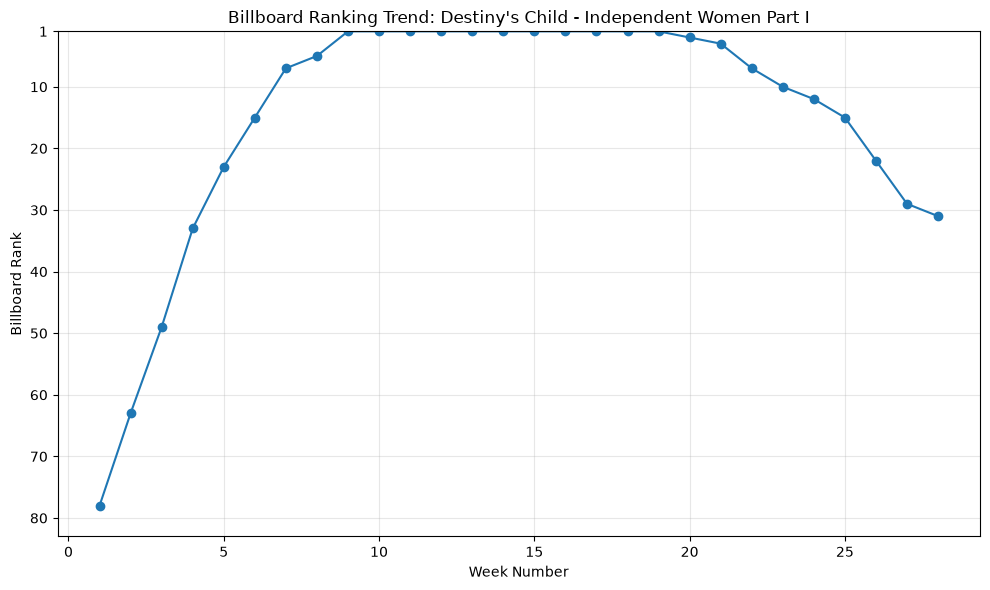

In [ ]:
# Select one song with a clear multi-week chart history
selected_song = billboard_clean[
    (billboard_clean["artist"] == "Destiny's Child")
    & (billboard_clean["track"] == "Independent Women Part I")
].copy()

# Sort observations by chart week
selected_song = selected_song.sort_values("Week_Number")

# Display summary information
print("Selected Song:")
print("Destiny's Child - Independent Women Part I")

print("\nNumber of Ranked Weeks:")
print(len(selected_song))

print("\nBest Rank:")
print(int(selected_song["Rank"].min()))

print("\nWeek of Best Rank:")
print(
    selected_song.loc[
        selected_song["Rank"].idxmin(),
        "Week_Number"
    ]
)

# Plot the ranking trajectory
plt.figure(figsize=(10, 6))

plt.plot(
    selected_song["Week_Number"],
    selected_song["Rank"],
    marker="o"
)

plt.title(
    "Billboard Ranking Trend: Destiny's Child - Independent Women Part I"
)
plt.xlabel("Week Number")
plt.ylabel("Billboard Rank")

# Smaller Billboard rank numbers are better,
# so rank 1 should appear at the top of the graph.
# plt.gca().invert_yaxis()
# Display higher rankings at the top, starting with rank 1
plt.ylim(selected_song["Rank"].max() + 5, 1)
plt.yticks([1, 10, 20, 30, 40, 50, 60, 70, 80])


plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Billboard Trend Observation

The selected song, **"Independent Women Part I" by Destiny's Child**, remained ranked for 28 weeks. It entered the chart at rank 78 and improved rapidly, reaching the number-one position for the first time in week 9. The song remained at or near the top of the chart for several weeks before its ranking gradually declined later in its chart run.

The y-axis is inverted because smaller Billboard rank numbers represent better chart positions. Therefore, movement upward on the graph represents an improvement in ranking.

### **Task 2.8 – Billboard Reflection**

Answer all questions:

1. Why was `melt()` appropriate for the weekly ranking columns?
2. Which string operations did you use and what did each accomplish?
3. Why should the cleaned week number be numeric?
4. How did you handle missing ranking values, and why?
5. What trend did your visualization reveal?
6. What data-quality issue could lead to an incorrect ranking trend?
7. How is this Billboard transformation more complex than the PEW transformation?

### Billboard Observations and Reflection

1. **Why was `melt()` appropriate for the weekly ranking columns?**  
   `melt()` was appropriate because the original dataset stored each week's ranking in a separate column. It converted the 65 weekly ranking columns into rows while preserving the song-level information, producing a more tidy structure with `Week` and `Rank` variables.

2. **Which string operations did you use and what did each accomplish?**  
   I used `str.strip()` to remove leading or trailing whitespace, `str.lower()` to standardize the text, `str.replace()` to remove the word `week`, and `str.extract()` to extract the numeric portion of each week label. The extracted week number was then converted to a numeric data type.

3. **Why should the cleaned week number be numeric?**  
   A numeric week number makes it possible to sort the observations correctly, perform calculations, create time-based visualizations, and calculate weekly chart dates. If the week values remained as text, values such as week 10 could be sorted incorrectly relative to week 2.

4. **How did you handle missing ranking values, and why?**  
   The reshaped dataset contained 15,298 missing ranking values out of 20,605 possible weekly observations. These rows were removed rather than imputed because a missing ranking indicates that the song did not have a recorded chart position for that week. Imputing a rank would create an artificial chart position that was not actually observed. After removing the missing values, 5,307 valid weekly ranking observations remained.

5. **What trend did your visualization reveal?**  
   "Independent Women Part I" by Destiny's Child entered the chart at rank 78 and improved quickly. It reached rank 1 for the first time in week 9 and remained at or near the top of the chart for several weeks before gradually declining later in its 28-week chart run.

6. **What data-quality issue could lead to an incorrect ranking trend?**  
   Incorrectly treating missing rankings as real values could distort the trend. For example, replacing missing rankings with zero or an average value would create chart positions that did not occur. Incorrectly cleaning or sorting the week labels could also place observations in the wrong chronological order.

7. **How is this Billboard transformation more complex than the PEW transformation?**  
   The Billboard transformation is more complex because, after reshaping, the week labels also require string cleaning and numeric conversion, the ranking values contain many missing observations that require treatment, and chart dates can be calculated from the entry date and week number. The PEW transformation mainly required reshaping the income categories from columns into rows.

# **Section 3 – Data Cleaning (Cars Dataset)**

## **Learning Topic: Data Cleaning and Missing Data Handling**

Data cleaning includes identifying invalid, irrelevant, duplicated, inconsistent, or missing data and deciding how to treat it.

In this section you will work with the Auto MPG / Cars dataset and compare several missing-data strategies.

### Required functions and concepts

- `isnull()` / `isna()`
- `notnull()` / `notna()`
- `dropna()`
- `fillna()`
- `mean()`
- `median()`
- `mode()`
- duplicate detection/removal
- numeric conversion
- `SimpleImputer`

## **Getting the Cars (Auto MPG) Dataset from the Internet**

Use the **Auto MPG** dataset from the UCI Machine Learning Repository. UCI describes it as a regression dataset concerning city-cycle fuel consumption. It contains variables such as MPG, cylinders, displacement, horsepower, weight, acceleration, model year, origin, and car name.

### Recommended source

Official UCI dataset page:

`https://archive.ics.uci.edu/dataset/9/auto+mpg`

The UCI page provides the dataset files and documentation. The raw file is named **`auto-mpg.data`** rather than `cars.csv`.

### Recommended student workflow

1. Open the UCI page above.
2. Download the Auto MPG dataset.
3. Extract the downloaded archive if necessary.
4. Locate **`auto-mpg.data`**.
5. Place it in your project's `data/` folder.
6. Keep the original raw file rather than editing it manually.

Your project can look like:

```text
project/
├── week5Lab.ipynb
└── data/
    └── auto-mpg.data
```

### Loading the UCI raw file with Pandas

Because this file is whitespace-delimited rather than a normal comma-separated CSV, supply the column names when reading it:

```python
column_names = [
    "MPG", "Cylinders", "Displacement", "Horsepower",
    "Weight", "Acceleration", "ModelYear", "Origin", "CarName"
]

cars = pd.read_csv(
    "./data/auto-mpg.data",
    sep=r"\s+",
    names=column_names,
    na_values="?",
    quotechar='"'
)
```

The `na_values="?"` argument is important because the UCI dataset uses `?` for missing horsepower values.

### Optional: create a local CSV working copy

After correctly loading the original UCI file, you may save a CSV copy:

```python
cars.to_csv("./data/cars.csv", index=False)
```

You can then reload it later with:

```python
cars = pd.read_csv("./data/cars.csv")
```

### Verify before continuing

Check:

```python
cars.shape
cars.head()
cars.dtypes
cars.isnull().sum()
```

The UCI version contains **398 instances**, and `Horsepower` contains missing values. If your results are substantially different, verify your download and loading code.

> **Good practice:** Preserve the original raw file. If you create `cars.csv`, treat it as a derived working copy rather than silently replacing the source data.

### **Task 3.1 – Load and Inspect the Cars Dataset**

1. Load the Cars dataset from your data folder.
2. Inspect shape, columns, data types, and sample rows.
3. Determine whether any row contains metadata or data-type labels rather than an actual car observation.
4. Remove irrelevant rows **only if justified by inspection**.

In [ ]:
# TODO: Load the Cars dataset.
# TODO: Inspect shape, columns, dtypes, head/tail.
# TODO: Remove any clearly irrelevant/non-data rows if present.

### **Task 3.2 – Assess Missing and Invalid Values**

1. Count missing values in every column.
2. Calculate the percentage of missing values.
3. Use `notnull()` or `notna()` at least once to confirm valid observations.
4. Check for values that should be numeric but are stored as text.
5. Convert columns to appropriate data types where needed.

In [ ]:
# TODO: Count and calculate percentages of missing values.
# TODO: Demonstrate notnull()/notna().
# TODO: Convert appropriate columns to numeric.

### **Task 3.3 – Check Duplicates**

Identify duplicate records.

- Report the number of duplicates.
- Remove duplicates if present.
- If there are none, state that clearly.

In [ ]:
# TODO: Detect duplicate rows.
# TODO: Remove duplicates if appropriate.

### **Task 3.4 – Compare Missing-Value Strategies**

Create copies of the data so you can compare approaches.

Demonstrate:

1. dropping rows with missing values using `dropna()`;
2. dropping columns with missing values and explaining why this may be too aggressive;
3. filling a numeric variable with its **mean**;
4. filling a numeric variable with its **median**;
5. using **mode** where appropriate for a categorical/discrete variable.

Do not automatically assume one strategy is best.

In [ ]:
# TODO: Demonstrate dropna() on rows.
# TODO: Demonstrate the effect of dropna(axis=1).
# TODO: Demonstrate mean, median, and mode imputation on suitable copies/columns.

### **Task 3.5 – Use Visualization to Support an Imputation Decision**

Choose a numeric feature such as `MPG`.

1. Plot its distribution.
2. Describe whether it appears symmetric or skewed.
3. Use that evidence to justify whether **mean or median** is a better simple imputation choice.

In [ ]:
# TODO: Plot the distribution of a numeric feature such as MPG.
# TODO: Calculate its mean and median.

### **Task 3.6 – Apply `SimpleImputer`**

Use Scikit-Learn's `SimpleImputer` on at least one appropriate feature.

Remember the two main stages:

1. `fit` – learn the replacement statistic from the data;
2. `transform` – replace missing values using that statistic.

You may use `fit_transform()` when appropriate, but explain what it combines.

In [ ]:
# TODO: Create a SimpleImputer.
# TODO: Fit it to one or more appropriate columns.
# TODO: Transform the data.
# TODO: Verify that the selected missing values were handled.

### **Task 3.7 – Validate the Cleaned Cars Dataset**

Compare the dataset **before and after cleaning**.

Report:

- shape;
- missing-value counts;
- duplicate counts;
- descriptive statistics for selected numeric columns.

Create at least **one visualization** supporting your comparison.

In [ ]:
# TODO: Compare before/after statistics and data quality.
# TODO: Create a supporting visualization.

### **Task 3.8 – Cars Reflection**

Answer all questions:

1. What were the main data-quality problems?
2. How many missing values did you find?
3. What happened when you dropped rows containing missing values?
4. Why might dropping entire columns be inappropriate?
5. When is mean imputation reasonable?
6. When might median be safer than mean?
7. Where would mode imputation be appropriate?
8. How did `SimpleImputer` differ from manually calling `fillna()`?
9. Did cleaning materially change the dataset statistics?
10. Which cleaning decisions would you carry forward into an ML pipeline, and why?

> **TODO – Cars observations and reflection:**  
> Write your answers here.

# **Section 4 – Outlier Detection (Diabetes Dataset)**

## **Learning Topic: Outlier Detection and Treatment**

An **outlier** is an observation that differs substantially from most of the data. Outliers can result from measurement errors, data-entry problems, unusual but legitimate cases, or genuinely rare events.

Outliers matter because they can affect:

- means and standard deviations;
- correlations;
- regression coefficients;
- distance-based algorithms;
- scaling and normalization;
- model evaluation.

**Important:** Detecting an outlier does **not** automatically mean it should be deleted. You must justify treatment in the context of the data.

## **Getting the Diabetes Dataset from the Internet**

For this section, use the **Pima Indians Diabetes** CSV commonly used in introductory machine-learning exercises. The expected version has **768 observations** and these nine columns:

`Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`, and `Outcome`.

### Recommended method — download in your browser

A public CSV copy is available here:

`https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv`

1. Open the address above in a browser.
2. Save the file as **`diabetes.csv`**.
3. Place it in your project's **`data`** folder.
4. Load the local copy:

```python
diabetes = pd.read_csv("./data/diabetes.csv")
```

### Optional Python-assisted download

```python
from pathlib import Path
import pandas as pd

Path("data").mkdir(exist_ok=True)

url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
diabetes = pd.read_csv(url)
diabetes.to_csv("./data/diabetes.csv", index=False)
```

### Verify before continuing

Run:

```python
diabetes.shape
diabetes.head()
diabetes.columns
```

For the expected file, the shape should be `(768, 9)` and the columns should match the list above.

### Important data-quality warning

In this dataset, some physiological variables contain **zero values** that may represent unavailable or invalid measurements rather than plausible measurements. Do not automatically treat every zero as an outlier or delete it. Inspect the variable meaning first, document your decision, and keep the focus of this section on comparing the required outlier-detection methods.

> **Dataset-name warning:** UCI also hosts a dataset simply called **Diabetes**, but it is a different time-series dataset. For this particular lab, use the nine-column Pima-style CSV described above so your work matches the assignment.

### **Task 4.1 – Load and Explore the Diabetes Dataset**

1. Load the Diabetes dataset from your data folder.
2. Display shape, columns, data types, and descriptive statistics.
3. Identify the numeric features you will examine for outliers.
4. Check for missing or obviously invalid values before outlier analysis.

In [ ]:
# TODO: Load the Diabetes dataset.
# TODO: Inspect shape, columns, dtypes, head(), and describe().
# TODO: Identify numeric features for outlier analysis.

### **Task 4.2 – Box Plot Method**

Create box plots for selected numeric features.

Use the plots to:

- identify observations outside the whiskers;
- compare which variables appear to contain more extreme values;
- explain what the box, median, quartiles, and whiskers represent.

In [ ]:
# TODO: Create one or more box plots.
# TODO: Label plots clearly.

### **Task 4.3 – Scatter Plot Method**

Create at least one scatter plot using two meaningful numeric features.

Use the plot to identify observations that appear isolated from the main cluster of data.

In [ ]:
# TODO: Create a scatter plot for two meaningful numeric features.
# TODO: Identify visually unusual observations.

### **Task 4.4 – Z-Score Method**

For a numeric feature, calculate:

\[
z = \frac{x - \mu}{\sigma}
\]

Use the conventional threshold:

\[
|z| > 3
\]

to flag potential outliers.

Report the number of observations identified.

In [ ]:
# TODO: Calculate Z-Scores for a selected numeric feature (or features).
# TODO: Identify rows where abs(z) > 3.
# TODO: Report the outlier count.

### **Task 4.5 – Interquartile Range (IQR) Method**

Calculate:

\[
IQR = Q3 - Q1
\]

Then calculate:

\[
Lower\ Bound = Q1 - 1.5(IQR)
\]

\[
Upper\ Bound = Q3 + 1.5(IQR)
\]

Identify observations outside those bounds and report the outlier count.

In [ ]:
# TODO: Calculate Q1, Q3, and IQR.
# TODO: Calculate lower and upper bounds.
# TODO: Identify and count IQR outliers.

### **Task 4.6 – Compare Detection Methods**

Create a small comparison showing the number of potential outliers identified by:

- Box Plot / IQR interpretation
- Z-Score
- IQR rule

Explain why the methods may identify different observations.

In [ ]:
# TODO: Summarize outlier counts from the different methods.

### **Task 4.7 – Treat Outliers Carefully**

Create a cleaned copy of the dataset and remove outliers **only where you can justify doing so**.

Do not overwrite the original dataframe.

Compare before and after:

- number of rows;
- mean;
- median;
- standard deviation;
- relevant visualizations.

In [ ]:
# TODO: Create a cleaned COPY of the data.
# TODO: Remove justified outliers using a clearly documented rule.
# TODO: Compare before/after statistics.
# TODO: Recreate at least one visualization after treatment.

### **Task 4.8 – Diabetes Reflection**

Answer all questions:

1. What is an outlier?
2. What are at least three possible causes of outliers?
3. Which variables showed the clearest visual outliers?
4. How many observations were flagged by the Z-Score method?
5. How many were flagged by the IQR method?
6. Why can Z-Score and IQR produce different results?
7. When should an outlier be retained?
8. When might removing an outlier be justified?
9. How did removal affect the descriptive statistics?
10. How could untreated outliers affect a downstream ML model?

> **TODO – Diabetes observations and reflection:**  
> Write your answers here.

# **Final Validation and Submission Checklist**

Before submitting:

- [ ] All four required sections are in this single notebook.
- [ ] PEW uses `pd.melt()` or `DataFrame.melt()`.
- [ ] Billboard uses `melt()` and Pandas string manipulation.
- [ ] Cars demonstrates missing-value analysis, dropping, imputation, duplicates, and validation.
- [ ] Diabetes includes box plot, scatter plot, Z-Score, and IQR.
- [ ] Every required visualization has a meaningful title and axis labels.
- [ ] Reflection questions are answered in Markdown.
- [ ] Data is loaded using relative paths from a clearly named data folder.
- [ ] `README.md`, `requirements.txt`, and `.gitignore` are included.
- [ ] There are no unnecessary `!pip install` cells.
- [ ] You restarted the kernel and successfully ran **Run All** from top to bottom.

# **General Guidelines**

## Expected Observations

### PEW
- Income categories are encoded as column headings in the original wide dataset.
- `melt()` should preserve religion as an identifier while moving income categories into rows.
- The long form is easier to group, filter, and visualize.

### Billboard
- Weekly rankings are stored across repeated week columns.
- `melt()` converts weekly columns into observations.
- Week labels usually require string cleanup/extraction before numeric analysis.
- Missing rankings often indicate that a song was not ranked in that week and should not automatically be imputed.

### Cars
- Students should inspect before deleting the first row; removal should be evidence-based.
- Some numeric-looking columns may require conversion from `object`.
- Mean imputation is sensitive to skew/outliers; median can be more robust.
- Dropping every column containing a missing value is generally too destructive when missingness is small.

### Diabetes
- Box plots and IQR are closely related but students should understand that visualization and rule-based detection serve different purposes.
- Z-Score works best when a roughly normal-distribution assumption is reasonable.
- IQR is more robust for skewed distributions.
- Outliers should not be removed automatically without context.

## Common Mistakes

- Using absolute paths such as `C:\Users\...`.
- Treating `melt()` as equivalent to simply renaming columns.
- Cleaning Billboard week labels without converting the result to numeric.
- Filling every missing value with zero.
- Dropping data without first reporting the effect.
- Using `|z| > 2` when the assignment specifies `|z| > 3`.
- Computing IQR incorrectly or reversing the lower/upper bound formulas.
- Removing outliers from the original dataframe and losing the baseline for comparison.
- Producing plots without titles, labels, or interpretation.
- Adding `!pip install` cells even though the project includes `requirements.txt`.

## Suggested Instructor Solutions / Checks

- Accept both `pd.melt(df, ...)` and `df.melt(...)`.
- Accept logically equivalent Pandas string-cleaning approaches.
- For missing values, grade the quality of the justification, not only the specific method selected.
- Require evidence that the notebook runs sequentially.
- Confirm that each data file is loaded from the submitted project using relative paths.

## Stretch Challenges

1. Build reusable functions for tidying and cleaning.
2. Compare multiple imputation strategies quantitatively.
3. Use `ColumnTransformer` or a Scikit-Learn preprocessing pipeline.
4. Compare outlier treatment before/after scaling.
5. Investigate how removing outliers changes a simple regression model.
6. Export cleaned datasets to a `processed/` subfolder without overwriting raw data.